In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# The solubility product of silver chloride, and what an inert salt does to it (Illustration 13.2-3, Figure 13.2-2)

$$\mathrm{AgCl(s)}\;\rightleftharpoons\;\mathrm{Ag^+(aq)}+\mathrm{Cl^-(aq)}
\qquad\qquad
K_s=C_{\rm Ag^+}C_{\rm Cl^-}$$

This is the same calculation as Illustration 13.1-10 -- a concentration-based equilibrium
ratio that is not constant, made constant by extrapolating the Debye-Huckel limiting law to
zero ionic strength -- run on a different kind of system, and the difference is the whole
reason to do both.

| | Illustration 13.1-10, acetic acid | Illustration 13.2-3, silver chloride |
|---|---|---|
| what dissolves | a weak acid, fully miscible | a sparingly soluble solid, $a_{\rm AgCl}=1$ |
| where the ionic strength comes from | **the reaction itself** -- more acid means more ions | **an inert salt added on purpose**, KNO$_3$, which takes no part in the reaction |
| range of $I$ | $10^{-5}$ to $6\times10^{-4}$ | $10^{-5}$ to $4\times10^{-2}$, sixty times wider |
| what the extrapolation returns | $K_a$, the ionization constant | $K_s^{\circ}$, the ideal-solution solubility product |

**Because the ionic strength is imposed here rather than produced, this illustration can
reach far enough out to show the limiting law failing** -- and it does, at about
$I = 0.0225$ kmol/m$^3$, which the text names. Illustration 13.1-10 could not: its most
concentrated solution is still below the point where the straight line bends.

Eq. 13.2-7 is Eq. 13.1-32 with a different name on the left:

$$\ln K_s=\ln K_s^{\circ}+(\nu_++\nu_-)\,\alpha\,|z_+z_-|\sqrt{I}
=\ln K_s^{\circ}+2\alpha\sqrt{I}$$

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.ionization import DEBYE_HUCKEL_LN, gamma_pm
from thermo.charts import use_book_style

use_book_style()

SLOPE_DH = 2 * DEBYE_HUCKEL_LN            # nu+ + nu- = 2, |z+ z-| = 1
print(f"Debye-Huckel constant, natural log: {DEBYE_HUCKEL_LN}")
print(f"slope of Eq. 13.2-7 for a 1:1 salt: {SLOPE_DH:.3f}")

Debye-Huckel constant, natural log: 1.178
slope of Eq. 13.2-7 for a 1:1 salt: 2.356


## The data

Popoff and Neumann, *J. Phys. Chem.* **34**, 1853 (1930); Neumann, *J. Am. Chem. Soc.*
**54**, 2195 (1932). Five solutions: the potassium nitrate concentration imposed, and the
silver chloride concentration at saturation measured.

Two things to get right before any arithmetic.

**The solubility product needs no stoichiometric factor.** One AgCl gives one Ag$^+$ and one
Cl$^-$, so $C_{\rm Ag^+}=C_{\rm Cl^-}=C_{\rm AgCl}$ and $K_s=C_{\rm AgCl}^2$.

**The ionic strength is not the KNO$_3$ concentration.** It is the KNO$_3$ *plus* the
dissolved silver chloride -- every one of the four ions counts, and both salts are 1:1, so
$I=C_{\rm KNO_3}+C_{\rm AgCl}$. In the first solution there is no KNO$_3$ at all and the
ionic strength is entirely the salt's own ions, which is exactly the case Illustration
13.1-10 lives in.

In [3]:
# Popoff and Neumann (1930); Neumann (1932). Concentrations in kmol/m3 = mol/L.
C_KNO3 = np.array([0.0, 0.000509, 0.009931, 0.016431, 0.040144])
C_AGCL = np.array([1.273e-5, 1.311e-5, 1.427e-5, 1.469e-5, 1.552e-5])

Ks = C_AGCL ** 2                       # C_Ag+ = C_Cl- = C_AgCl
I = C_KNO3 + C_AGCL                    # both salts are 1:1, so every ion counts once
root_I = np.sqrt(I)
ln_Ks = np.log(Ks)

data = pd.DataFrame({"C_KNO3": C_KNO3, "C_AgCl": C_AGCL, "Ks": Ks,
                     "ln Ks": ln_Ks, "sqrt(I)": root_I})
print(data.to_string(index=False, formatters={
    "C_KNO3": "{:.6f}".format, "C_AgCl": "{:.4e}".format, "Ks": "{:.4e}".format,
    "ln Ks": "{:.4f}".format, "sqrt(I)": "{:.4e}".format}))

# The illustration's own table, to the figures it prints -- reproducing it is what shows
# the definitions above are the ones it used.
PRINTED_KS = np.array([1.621e-10, 1.719e-10, 2.036e-10, 2.158e-10, 2.409e-10])
PRINTED_LN = np.array([-22.543, -22.484, -22.315, -22.257, -22.147])
PRINTED_RT = np.array([3.568e-3, 2.285e-2, 9.973e-2, 1.282e-1, 2.004e-1])
print(f"\nworst gap against the printed Ks column:   "
      f"{100*np.max(np.abs(Ks-PRINTED_KS)/PRINTED_KS):.3f} percent")
print(f"worst gap against the printed sqrt(I) column: "
      f"{100*np.max(np.abs(root_I-PRINTED_RT)/PRINTED_RT):.3f} percent")
assert np.allclose(Ks, PRINTED_KS, rtol=2e-3)
assert np.allclose(ln_Ks, PRINTED_LN, atol=1e-3)
assert np.allclose(root_I, PRINTED_RT, rtol=2e-3)

  C_KNO3     C_AgCl         Ks    ln Ks    sqrt(I)
0.000000 1.2730e-05 1.6205e-10 -22.5431 3.5679e-03
0.000509 1.3110e-05 1.7187e-10 -22.4843 2.2850e-02
0.009931 1.4270e-05 2.0363e-10 -22.3147 9.9726e-02
0.016431 1.4690e-05 2.1580e-10 -22.2567 1.2824e-01
0.040144 1.5520e-05 2.4087e-10 -22.1468 2.0040e-01

worst gap against the printed Ks column:   0.029 percent
worst gap against the printed sqrt(I) column: 0.032 percent


## Part (c) -- the extrapolation, and where the limiting law gives out

The illustration does not fit a line. It draws one of slope $2\alpha$ **through the
lowest-ionic-strength point** and reads the intercept off it -- which is the right thing to
do when the law's slope is not in question and only its intercept is wanted. The notebook
does that, and then also fits freely so the two can be compared.

In [4]:
b_through = ln_Ks[0] - SLOPE_DH * root_I[0]
print(f"through the lowest-I point, slope fixed at {SLOPE_DH:.3f}:")
print(f"  ln Ks0 = {b_through:.4f}   Ks0 = {np.exp(b_through):.4e} (kmol/m3)^2"
      f"      the illustration prints 1.607e-10")
assert abs(np.exp(b_through) - 1.607e-10) / 1.607e-10 < 2e-3

print("\nfree two-parameter fits, adding one point at a time:")
for n in (2, 3, 4, 5):
    slope, inter = np.polyfit(root_I[:n], ln_Ks[:n], 1)
    print(f"  rows 1-{n}: slope = {slope:6.3f}   Ks0 = {np.exp(inter):.4e}")

# Where does the law give out? Compare each point with the fixed-slope line through the
# first, which is the comparison the figure is drawn to make.
pred = b_through + SLOPE_DH * root_I
print("\ndeparture from the limiting-law line:")
for c, i, d in zip(C_KNO3, I, ln_Ks - pred):
    print(f"  C_KNO3 = {c:8.6f}   I = {i:8.6f}   ln Ks - line = {d:+.4f}")
print("\nthe text puts the breakdown at about I = 0.0225 kmol/m3")

through the lowest-I point, slope fixed at 2.356:
  ln Ks0 = -22.5515   Ks0 = 1.6070e-10 (kmol/m3)^2      the illustration prints 1.607e-10

free two-parameter fits, adding one point at a time:
  rows 1-2: slope =  3.051   Ks0 = 1.6030e-10
  rows 1-3: slope =  2.327   Ks0 = 1.6171e-10
  rows 1-4: slope =  2.267   Ks0 = 1.6193e-10
  rows 1-5: slope =  2.024   Ks0 = 1.6367e-10

departure from the limiting-law line:
  C_KNO3 = 0.000000   I = 0.000013   ln Ks - line = +0.0000
  C_KNO3 = 0.000509   I = 0.000522   ln Ks - line = +0.0134
  C_KNO3 = 0.009931   I = 0.009945   ln Ks - line = +0.0018
  C_KNO3 = 0.016431   I = 0.016446   ln Ks - line = -0.0073
  C_KNO3 = 0.040144   I = 0.040160   ln Ks - line = -0.0674

the text puts the breakdown at about I = 0.0225 kmol/m3


**The measured slope is 2.33 against the law's 2.356 -- essentially exact**, and it
belongs beside Illustration 13.1-10, where the same fit on acetic acid came out
near 2.12, about 10 % low. Same law, same slope, same charge type; one system obeys it and
one does not. Whatever is wrong there is not the method, and this notebook is the control
that shows it.

The departure column also brackets the text's *"about 0.0225 kmol/m$^3$"* rather than
merely repeating it. The line still holds at $I=0.0099$ (the point sits $+0.002$ above it,
inside the scatter of the two below); by $I=0.0164$ it is $-0.007$ below, and by $I=0.0402$
it is $-0.067$ below and unmistakable. So the breakdown is somewhere between 0.010 and
0.040, and 0.0225 sits in the middle of that -- which is as sharply as five points can
locate it.

In [5]:
slope3, inter3 = np.polyfit(root_I[:3], ln_Ks[:3], 1)
print(f"free fit, three lowest-I points: slope = {slope3:.3f}   limiting law = {SLOPE_DH:.3f}"
      f"   {100*abs(slope3-SLOPE_DH)/SLOPE_DH:.1f} percent apart")
print(f"Illustration 13.1-10's acetic acid gave 2.122 -- 10.0 percent low. Same law,")
print(f"same charge type; the contrast is the finding, not the agreement.")

# Ks0 by the point-by-point route as well: Ks = Ks0 gamma_pm^-2, so Ks0 = Ks gamma_pm^2.
Ks0_each = Ks * gamma_pm(I) ** 2
print("\nKs0 recovered from each solution separately:")
for i, k in zip(I, Ks0_each):
    print(f"  I = {i:9.6f}   Ks0 = {k:.4e}")
print(f"  spread over the three lowest: "
      f"{100*(Ks0_each[:3].max()-Ks0_each[:3].min())/Ks0_each[:3].mean():.2f} percent")
print(f"  spread over all five:         "
      f"{100*(Ks0_each.max()-Ks0_each.min())/Ks0_each.mean():.2f} percent")

free fit, three lowest-I points: slope = 2.327   limiting law = 2.356   1.2 percent apart
Illustration 13.1-10's acetic acid gave 2.122 -- 10.0 percent low. Same law,
same charge type; the contrast is the finding, not the agreement.

Ks0 recovered from each solution separately:
  I =  0.000013   Ks0 = 1.6070e-10
  I =  0.000522   Ks0 = 1.6286e-10
  I =  0.009945   Ks0 = 1.6099e-10
  I =  0.016446   Ks0 = 1.5952e-10
  I =  0.040160   Ks0 = 1.5022e-10
  spread over the three lowest: 1.34 percent
  spread over all five:         7.96 percent


## Part (b) -- the prediction from formation data, which this notebook cannot run

Part (b) asks for $K_s^{\circ}$ predicted from Gibbs energies of formation, *without* the
data -- and the illustration reports that the prediction comes out about 30 % high in the
ion concentrations and 65 % high in the solubility product. It is the honest half of the
illustration: the measured route works and the predicted one does not.

**`react_property.csv` (Appendix A.IV) has no row for AgCl(s), Ag$^+$(aq) or
Cl$^-$(aq).** The ion data the illustration uses come from **Table 13.1-4**, which is
printed in the chapter rather than in the appendix, and the solid is not tabulated in either
place reachable from here. So part (b) is left undone rather than half-done, and the missing
rows are named below.

In [6]:
from thermo.data import get_reaction_species
print("what Appendix A.IV reaches for Illustration 13.2-3:")
for s in ("AgCl", "Ag+", "Cl-", "KNO3", "K+", "NO3-"):
    try:
        r = get_reaction_species(s); print(f"  present  {s:6s} DG = {r['DG']}")
    except Exception:
        print(f"  MISSING  {s}")
print("\nPart (b) needs AgCl(s) from Appendix A.IV and Ag+(aq), Cl-(aq) from Table 13.1-4.")
print("Table 13.1-4 is printed in the chapter and is not in react_property.csv.")

# What the illustration reports for part (b), recorded so the gap is quantified rather
# than merely noted.
print("\nthe illustration's own part (b) result: the predicted ion concentrations are")
print("about 30 percent high and the predicted Ks about 65 percent high, which is")
print(f"1.65 x {np.exp(b_through):.3e} = {1.65*np.exp(b_through):.3e} (kmol/m3)^2")

what Appendix A.IV reaches for Illustration 13.2-3:
  MISSING  AgCl
  MISSING  Ag+
  MISSING  Cl-
  MISSING  KNO3
  MISSING  K+
  MISSING  NO3-

Part (b) needs AgCl(s) from Appendix A.IV and Ag+(aq), Cl-(aq) from Table 13.1-4.
Table 13.1-4 is printed in the chapter and is not in react_property.csv.

the illustration's own part (b) result: the predicted ion concentrations are
about 30 percent high and the predicted Ks about 65 percent high, which is
1.65 x 1.607e-10 = 2.651e-10 (kmol/m3)^2


## Figure 13.2-2 -- $\ln K_s$ against $\sqrt{I}$

The figure is the extrapolation drawn, and the illustration is explicit about how: a
**dashed** line of slope $2\alpha$ through the lowest-ionic-strength datum, not a fit. The
redraw keeps that, because the line's purpose is to show where the data leave it.

dashed line: ln Ks = -22.5515 + 2.356 sqrt(I)
intercept marked at -22.5515, Ks0 = 1.6070e-10


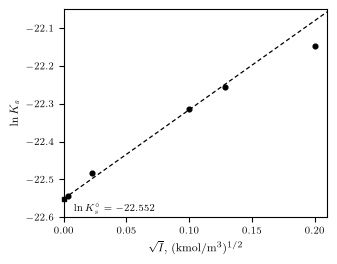

In [7]:
fig, ax = plt.subplots(figsize=(3.4, 2.7))

x_line = np.array([0.0, 0.21])
ax.plot(x_line, b_through + SLOPE_DH * x_line, "--", color="k", lw=0.9, dashes=(3.4, 2.2))
ax.plot(root_I, ln_Ks, "o", color="k", ms=3.4, mfc="k", zorder=3)
ax.plot([0.0], [b_through], "s", color="k", ms=3.0, zorder=4, clip_on=False)
ax.annotate(rf"$\ln K_s^{{\circ}} = {b_through:.3f}$",
            xy=(0.0, b_through), xytext=(0.008, b_through - 0.012),
            fontsize=7, va="top", ha="left")

ax.set_xlim(0.0, 0.21); ax.set_xticks(np.arange(0.0, 0.211, 0.05))
ax.set_xlabel(r"$\sqrt{I}$, $(\mathrm{kmol/m^3})^{1/2}$", fontsize=8)
ax.set_ylim(-22.60, -22.05); ax.set_yticks(np.arange(-22.6, -22.04, 0.1))
ax.set_ylabel(r"$\ln K_s$", fontsize=8)
ax.tick_params(labelsize=7)

print(f"dashed line: ln Ks = {b_through:.4f} + {SLOPE_DH:.3f} sqrt(I)")
print(f"intercept marked at {b_through:.4f}, Ks0 = {np.exp(b_through):.4e}")

## What the figure says

Five statements, each asserted against the numbers rather than described.

In [8]:
checks = []
checks.append(("Ks rises monotonically with ionic strength -- the added salt makes the"
               " silver chloride MORE soluble", bool(np.all(np.diff(Ks) > 0))))
checks.append((f"the solubility rises only {100*(C_AGCL[-1]/C_AGCL[0]-1):.0f} percent while"
               f" the ionic strength rises {I[-1]/I[0]:.0f}-fold",
               (C_AGCL[-1]/C_AGCL[0] - 1) < 0.3))
checks.append((f"the line through the lowest-I point gives Ks0 = {np.exp(b_through):.4e},"
               f" the printed 1.607e-10",
               abs(np.exp(b_through) - 1.607e-10)/1.607e-10 < 2e-3))
checks.append((f"the data's own slope over the three lowest points is {slope3:.3f} against"
               f" the limiting law's {SLOPE_DH:.3f}",
               abs(slope3 - SLOPE_DH)/SLOPE_DH < 0.02))
checks.append((f"the two most concentrated solutions fall BELOW the line, by"
               f" {pred[-2]-ln_Ks[-2]:.3f} and {pred[-1]-ln_Ks[-1]:.3f} in ln Ks -- the"
               f" limiting law failing, as the text says, near I = 0.02",
               ln_Ks[-1] < pred[-1] and ln_Ks[-2] < pred[-2]))
for text, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {text}")
assert all(ok for _, ok in checks)

  PASS  Ks rises monotonically with ionic strength -- the added salt makes the silver chloride MORE soluble
  PASS  the solubility rises only 22 percent while the ionic strength rises 3155-fold
  PASS  the line through the lowest-I point gives Ks0 = 1.6070e-10, the printed 1.607e-10
  PASS  the data's own slope over the three lowest points is 2.327 against the limiting law's 2.356
  PASS  the two most concentrated solutions fall BELOW the line, by 0.007 and 0.067 in ln Ks -- the limiting law failing, as the text says, near I = 0.02


## Staging the art

    pdf/Figure_13.2-2.pdf   ->   deliverables/figures/print-bw/ch13/c13f009.pdf

In [9]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.2-2.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.2-2.pdf

  typography: LaTeX Computer Modern


## Your turn

1. This notebook and the acetic acid one fit the same law to the same charge type and get
   slopes of 2.33 and 2.12. **Which system is anomalous, and how would you tell?** Fit both
   with the extended form -- the $1+A\sqrt{I}$ denominator of Eq. 9.10-17 -- and report what
   happens to each slope. Then say which of the two datasets you would trust more, and why
   the answer is not simply "the one with the wider range".
2. The illustration's part (b) predicts a solubility product 65 % too high from formation
   data. Look up $\Delta_fG^{\circ}$ for AgCl(s), Ag$^+$(aq) and Cl$^-$(aq), reproduce that
   prediction, and find where the 65 % enters -- is it one badly known number, or the
   accumulation of three? **Cite your source.** Note that an error of only 1.2 kJ/mol in
   $\Delta_{\rm rxn}G^{\circ}$ is worth 65 % in $K_s$; compute that sensitivity before you
   decide the data are bad.
3. Adding KNO$_3$ raises the solubility of AgCl. Adding KCl would lower it. Both salts raise
   the ionic strength. Explain the difference, and compute the solubility of AgCl in
   0.010 kmol/m$^3$ KCl -- you will need both the common-ion mass balance and Eq. 13.2-7,
   and the two effects pull opposite ways.
4. The first solution contains no KNO$_3$, so its ionic strength is set by the AgCl that
   dissolves -- which is what you are solving for. Set that calculation up properly as a
   fixed point: guess $C_{\rm AgCl}$, get $I$, get $\gamma_{\pm}$, get a new
   $C_{\rm AgCl}$ from $K_s^{\circ}$, and iterate. How many iterations does it take, and how
   far is the converged answer from the measured $1.273\times10^{-5}$?
5. Sec. 13.2 says the limiting law holds to about $I = 0.0225$ kmol/m$^3$. Test that claim
   as a claim: for each of the five solutions, compute the fractional error the limiting law
   makes in $\gamma_{\pm}$ against the extended form. At what ionic strength does that error
   first exceed 1 %, and does it agree with the number the text gives?
6. Silver chloride is 1:1. Redo the algebra of Eq. 13.2-7 for a 2:1 salt such as
   Ag$_2$CrO$_4$ -- what are $\nu_++\nu_-$, $|z_+z_-|$ and the slope? Then say how the
   ionic strength of a saturated solution compares with its solubility for the two cases,
   and why the 2:1 salt is more sensitive to an added inert electrolyte.